<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação em Ciência dos Alimentos: Temperatura x Consumo de Cerveja

**Pergunta-problema:** A temperatura média do dia influencia o consumo de cerveja na cidade de São Paulo?

**Fonte dos dados:** Dataset público *Beer Consumption — São Paulo* (Kaggle, coletado por estudante de pós-graduação USP, ano-base 2015; 365 observações diárias, sem valores ausentes após limpeza). Disponível em: https://www.kaggle.com/datasets/dongeorge/beer-consumption-sao-paulo

Variáveis:
- `Temperatura Media (C)`, `Temperatura Minima (C)`, `Temperatura Maxima (C)`: temperaturas diárias
- `Precipitacao (mm)`: chuva do dia
- `Final de Semana`: indicador binário (1 = sábado/domingo)
- `Consumo de cerveja (litros)`: variável resposta (consumo diário)

# Carregar bibliotecas e dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import os # Import os module for file operations



In [ ]:
df = pd.read_csv('dados_semana04.csv')
df.head()

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,27.30,23.9,32.5,0.0,0.0,25.461
1,2015-01-02,27.02,24.5,33.5,0.0,0.0,28.972
2,2015-01-03,24.82,22.4,29.9,0.0,1.0,30.814
3,2015-01-04,23.98,21.5,28.6,1.2,1.0,29.799
4,2015-01-05,23.82,21.0,28.3,0.0,0.0,28.900


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Data                         365 non-null    object 
 1   Temperatura Media (C)        365 non-null    float64
 2   Temperatura Minima (C)       365 non-null    float64
 3   Temperatura Maxima (C)       365 non-null    float64
 4   Precipitacao (mm)            365 non-null    float64
 5   Final de Semana              365 non-null    float64
 6   Consumo de cerveja (litros)  365 non-null    float64
dtypes: float64(6), object(1)
memory usage: 20.1+ KB


In [ ]:
df.describe().round(2)

,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
count,365.00,365.00,365.00,365.00,365.00,365.00
mean,21.23,17.46,26.61,5.20,0.28,25.40
std,3.18,2.83,4.32,12.42,0.45,4.40
min,12.90,10.60,14.50,0.00,0.00,14.34
25%,19.02,15.30,23.80,0.00,0.00,22.01
50%,21.38,17.90,26.90,0.00,0.00,24.87
75%,23.28,19.60,29.40,3.20,1.00,28.63
max,28.86,24.50,36.50,94.80,1.00,37.94


# Coeficiente de Correlação Linear de Pearson ($r$)

O coeficiente de correlação linear de Pearson, denotado por $r$, mede a força e a direção da associação linear entre duas variáveis quantitativas $X$ e $Y$.

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

**Casos Extremos:**

*   **$r = 1$**: Correlação linear positiva perfeita. Todos os pontos caem sobre uma linha reta com inclinação positiva. À medida que $X$ aumenta, $Y$ aumenta proporcionalmente.
*   **$r = 0$**: Nenhuma correlação linear. Não há uma relação linear discernível entre $X$ e $Y$. Isso não significa ausência de *qualquer* relação, apenas ausência de uma relação *linear*.
*   **$r = -1$**: Correlação linear negativa perfeita. Todos os pontos caem sobre uma linha reta com inclinação negativa. À medida que $X$ aumenta, $Y$ diminui proporcionalmente.





In [ ]:
x = df['Temperatura Media (C)']
y = df['Consumo de cerveja (litros)']

r_result = stats.pearsonr(x, y)
r = r_result.statistic

print(f'Coeficiente de correlação de Pearson (r) = {r:.4f}')


Coeficiente de correlação de Pearson (r) = 0.5746


**Interpretação:** r ≈ 0,57 indica correlação linear positiva de magnitude moderada a forte.

⚠️ **Correlação não implica causalidade**: dias mais quentes podem coincidir com finais de semana de verão, festas ou outros fatores de confusão (*confounders*).

# Modelo de Regressão Linear Simples

O modelo de regressão linear simples descreve a relação entre uma variável dependente $Y$ e uma única variável independente $X$ através de uma linha reta, incluindo um termo de erro aleatório ($\epsilon$):

$$
Y_i = \beta_0 + \beta_1 X_i + \epsilon_i
$$

em que:
*   $Y_i$: é a $i$-ésima observação da variável dependente.
*   $X_i$: é a $i$-ésima observação da variável independente.
*   $\beta_0$: é o intercepto (ou coeficiente linear), o valor esperado de $Y$ quando $X=0$.
*   $\beta_1$: é o coeficiente angular (ou coeficiente de inclinação), a mudança esperada em $Y$ para cada unidade de mudança em $X$.
*   $\epsilon_i$: é o termo de erro aleatório, representando a variação em $Y$ que não é explicada por $X$. Assume-se que $\epsilon_i$ tem média zero, variância constante e é não correlacionado.




# Estimação dos Parâmetros por Mínimos Quadrados (OLS)

Os parâmetros $\beta_0$ e $\beta_1$ do modelo de regressão linear simples são estimados a partir dos dados amostrais usando o método dos Mínimos Quadrados Ordinários (OLS), que busca minimizar a soma dos quadrados dos resíduos (as diferenças entre os valores observados de $Y$ e os valores preditos pelo modelo $\hat{Y}$).

As estimativas dos parâmetros, $\hat{\beta_0}$ e $\hat{\beta_1}$ são dadas por:

$$
\hat{\beta_1} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

$$
\hat{\beta_0} = \bar{y} - \hat{\beta_1}\bar{x}
$$

em que $\bar{x}$ e $\bar{y}$ são as médias amostrais de $X$ e $Y$, respectivamente.



# Interpretação Prática dos Parâmetros Estimados:

*   **Intercepto ($\hat{\beta_0}$):** Representa o valor *esperado* da variável dependente ($Y$) quando a variável independente ($X$) é zero. É importante considerar se $X=0$ faz sentido no contexto prático dos dados. Se $X=0$ está fora do intervalo de valores observados de $X$, a interpretação do intercepto pode ser uma extrapolação e deve ser feita com cautela.

*   **Coeficiente Angular ($\hat{\beta_1}$):** Indica a mudança *média esperada* na variável dependente ($Y$) para cada aumento de uma unidade na variável independente ($X$), mantendo outras variáveis constantes. Um $\hat{\beta_1}$ positivo sugere uma relação positiva (quando $X$ aumenta, $Y$ tende a aumentar), enquanto um $\hat{\beta_1}$ negativo sugere uma relação negativa (quando $X$ aumenta, $Y$ tende a diminuir).



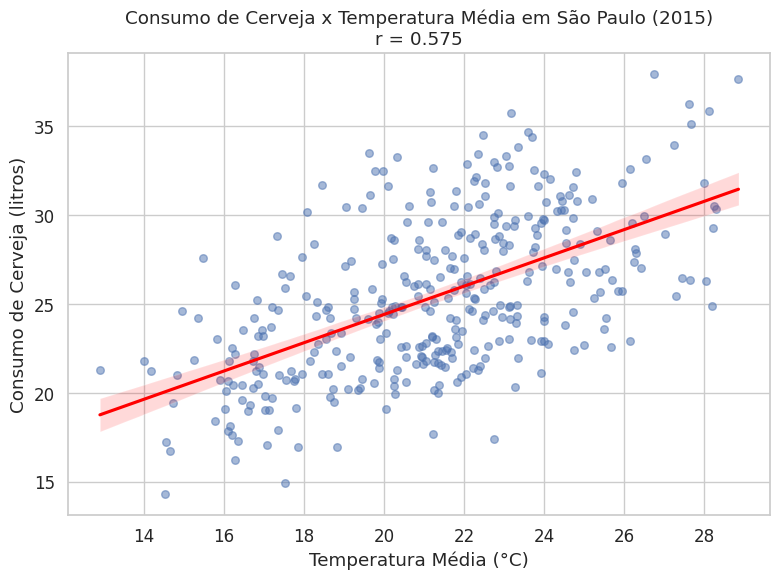

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(x='Temperatura Media (C)', y='Consumo de cerveja (litros)', data=df,
            scatter_kws={'alpha':0.5, 's':30}, line_kws={'color':'red'})
plt.title(f'Consumo de Cerveja x Temperatura Média em São Paulo (2015)\nr = {r:.3f}')
plt.xlabel('Temperatura Média (°C)')
plt.ylabel('Consumo de Cerveja (litros)')
plt.tight_layout()
plt.show()

# Ajuste do modelo de regressão linear (statsmodels OLS)

In [ ]:
X = sm.add_constant(x)  # adiciona a coluna do intercepto (beta0)
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                                 OLS Regression Results                                
Dep. Variable:     Consumo de cerveja (litros)   R-squared:                       0.330
Model:                                     OLS   Adj. R-squared:                  0.328
Method:                          Least Squares   F-statistic:                     178.9
Date:                         Mon, 24 Aug 2026   Prob (F-statistic):           1.87e-33
Time:                                 18:06:16   Log-Likelihood:                -984.99
No. Observations:                          365   AIC:                             1974.
Df Residuals:                              363   BIC:                             1982.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

# Interpretação dos coeficientes

- **Intercepto (β0) ≈ 8,53**: consumo médio estimado de cerveja quando a temperatura é 0°C (extrapolação teórica, fora do intervalo observado — cuidado ao interpretar literalmente).
- **Inclinação (β1) ≈ 0,795**: para cada aumento de 1°C na temperatura média, o consumo esperado de cerveja aumenta em aproximadamente 0,795 litros, mantendo-se as demais condições.
- **R² ≈ 0,330**: a temperatura média explica cerca de 33% da variabilidade total do consumo de cerveja. Os outros 67% são explicados por outras variáveis (dia da semana, chuva, eventos) e variação aleatória.


# Como fazer previsão?

In [ ]:
temperaturas_para_prever = pd.DataFrame({'Temperatura Media (C)': [16, 18, 24]})
consumo_previsto = reg.predict(temperaturas_para_prever)

resultados_previsao = temperaturas_para_prever.copy()
resultados_previsao['Consumo de Cerveja Previsto (litros)'] = consumo_previsto

print('Previsões de Consumo de Cerveja:')
print(resultados_previsao.round(2))

Previsões de Consumo de Cerveja:
   Temperatura Media (C)  Consumo de Cerveja Previsto (litros)
0                     16                                 21.25
1                     18                                 22.84
2                     24                                 27.61
